# Task 7 — Multi-Tier Network Integration

Combines regional nodes, gateway nodes, regions, areas, and interface boundary nodes
into a single hierarchical network catalog; produces publication-quality maps and diagrams.

All structural tables already exist from Tasks 2–6. No new MIP or clustering runs here.

**Subtasks:**
- 7.1 Unified Node Catalog (`nodes.csv`, 391 rows)
- 7.2 Unified Edge Catalog (`edges.csv`, ~584 rows)
- 7.3 Multi-Tier Map Figure
- 7.4 Hierarchy Schematic
- 7.5 Exports & Validation

**Interpreter:** `~/.venvs/general/bin/python3`

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.collections import LineCollection
from pyproj import Transformer
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150

ROOT = Path('/Users/tianyihu/Documents/Dev/Python/Projects/ISYE6339_Case2')
D    = ROOT / 'Data'
OUT  = D / 'Task7'
FIG  = OUT / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# Projection helper: WGS-84 → EPSG:9311 (always_xy: input is lon,lat)
wgs_to_9311 = Transformer.from_crs('EPSG:4326', 'EPSG:9311', always_xy=True)

def to_9311(lon, lat):
    """Project arrays of (lon, lat) degrees to EPSG:9311 (x_m, y_m)."""
    return wgs_to_9311.transform(lon, lat)

def slugify(s):
    """Stable slug: lowercase, non-alphanumeric chars → space, spaces → underscore."""
    s = re.sub(r'[^a-zA-Z0-9\s]', ' ', str(s))
    return re.sub(r'\s+', '_', s.strip().lower())

print('Setup complete. Output dir:', OUT)

Setup complete. Output dir: /Users/tianyihu/Documents/Dev/Python/Projects/ISYE6339_Case2/Data/Task7


## Task 7.1 — Unified Node Catalog

Assemble one row per network node across all tiers:

| Tier | Count | Source |
|------|-------|--------|
| Regional hubs (`RH_`) | 50 | `Data/Task5/selected_hubs.csv` |
| Gateway hubs (`GW_`) | 312 | `Data/Task6/gateway_selected.csv` |
| Interface nodes (`IF_`) | 29 | `Data/Task2/task2_*_interface_nodes_final.csv` |

Interface node lat/lon are hardcoded (not in Task 2 CSVs). Continental tier
`tons_2025`/`tons_2030` are raw short tons → divide by 1,000 to get ktons.

In [2]:
# ── 7.1a — Regional Hubs (50) ─────────────────────────────────────────────────
rh_raw = pd.read_csv(D / 'Task5/selected_hubs.csv')

rh = pd.DataFrame({
    'node_id':                   'RH_' + rh_raw['candidate_id'].astype(str),
    'node_type':                 'regional_hub',
    'tier':                      1,
    'candidate_id':              rh_raw['candidate_id'].astype(str),
    'facility_name':             rh_raw['facility_name'],
    'city':                      rh_raw['city'],
    'source_state':              rh_raw['source_state'],
    'latitude':                  rh_raw['latitude'],
    'longitude':                 rh_raw['longitude'],
    'usable_available_space_sf': rh_raw['usable_available_space_sf'],
    'region_id':                 rh_raw['region_id'],
    'area_id':                   None,
    'interface_class':           None,
    'tons_2025_ktons':           np.nan,
    'tons_2030_ktons':           np.nan,
})

print(f'Regional hubs: {len(rh)} rows')
assert len(rh) == 50, f'Expected 50 regional hubs, got {len(rh)}'
rh.head(2)

Regional hubs: 50 rows


,node_id,node_type,tier,candidate_id,facility_name,city,source_state,latitude,longitude,usable_available_space_sf,region_id,area_id,interface_class,tons_2025_ktons,tons_2030_ktons
0,RH_T4-CT-00017,regional_hub,1,T4-CT-00017,Shepard's Warehouse,Bethel,CT,41.366507,-73.416687,378947,48,None,None,NaN,NaN
1,RH_T4-CT-00024,regional_hub,1,T4-CT-00024,"61 Chapel Rd, Manchester, CT",Manchester,CT,41.795684,-72.570263,485000,8,None,None,NaN,NaN


In [3]:
# ── 7.1b — Gateway Hubs (312) ─────────────────────────────────────────────────
gw_raw = pd.read_csv(D / 'Task6/gateway_selected.csv')

# Derive area_id: take the first area from the pipe-separated areas_served column
gw_raw['area_id'] = gw_raw['areas_served'].astype(str).str.split('|').str[0]

gw = pd.DataFrame({
    'node_id':                   'GW_' + gw_raw['candidate_id'].astype(str),
    'node_type':                 'gateway_hub',
    'tier':                      2,
    'candidate_id':              gw_raw['candidate_id'].astype(str),
    'facility_name':             gw_raw['facility_name'],
    'city':                      gw_raw['city'],
    'source_state':              gw_raw['source_state'],
    'latitude':                  gw_raw['latitude'],
    'longitude':                 gw_raw['longitude'],
    'usable_available_space_sf': gw_raw['usable_available_space_sf'],
    'region_id':                 gw_raw['region_id'],
    'area_id':                   gw_raw['area_id'],
    'interface_class':           None,
    'tons_2025_ktons':           np.nan,
    'tons_2030_ktons':           np.nan,
})

print(f'Gateway hubs: {len(gw)} rows')
assert len(gw) == 312, f'Expected 312 gateway hubs, got {len(gw)}'
gw.head(2)

Gateway hubs: 312 rows


,node_id,node_type,tier,candidate_id,facility_name,city,source_state,latitude,longitude,usable_available_space_sf,region_id,area_id,interface_class,tons_2025_ktons,tons_2030_ktons
0,GW_T4-CT-00009,gateway_hub,2,T4-CT-00009,"30 Forbes Rd, Dayville, CT",Dayville,CT,41.859577,-71.907714,460000,44,44_3,None,NaN,NaN
1,GW_T4-CT-00018,gateway_hub,2,T4-CT-00018,"475 Knotter Dr, Cheshire, CT",Cheshire,CT,41.544547,-72.922850,356612,8,8_2,None,NaN,NaN


In [4]:
# ── 7.1c — Interface Nodes (29) ───────────────────────────────────────────────
# Approximate coordinates hardcoded (Task 2 CSVs have no lat/lon)
IF_COORDS = {
    # Global — seaports
    'Hampton Roads, VA':                           (36.851, -76.286),
    'Philadelphia, PA':                            (39.920, -75.170),
    # Global — cargo airports
    'WASHINGTON DULLES INTL':                      (38.953, -77.456),
    'BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL': (39.175, -76.669),
    'GENERAL EDWARD LAWRENCE LOGAN INTL':          (42.366, -71.010),
    'NEWARK LIBERTY INTL':                         (40.689, -74.174),
    'JOHN F KENNEDY INTL':                         (40.641, -73.778),
    'PHILADELPHIA INTL':                           (39.873, -75.244),
    'PITTSBURGH INTL':                             (40.491, -80.233),
    # Continental — US-Canada border crossings
    'Buffalo Niagara Falls':                       (42.901, -79.008),
    'Champlain Rouses Point':                      (44.989, -73.442),
    'Alexandria Bay':                              (44.336, -75.918),
    'Derby Line':                                  (45.003, -72.097),
    'Highgate Springs':                            (45.018, -73.017),
    'Houlton':                                     (46.126, -67.840),
    'Jackman':                                     (45.629, -70.253),
    'Calais':                                      (45.182, -67.277),
    # National — external county seats
    'LUCAS, OH':                                   (41.653, -83.538),
    'HARRIS, TX':                                  (29.760, -95.370),
    'COOK, IL':                                    (41.878, -87.630),
    'FRANKLIN, OH':                                (39.961, -82.999),
    'CUYAHOGA, OH':                                (41.499, -81.694),
    'HAMILTON, OH':                                (39.103, -84.512),
    'LOS ANGELES, CA':                             (34.052, -118.244),
    'WEBB, TX':                                    (27.506, -99.507),
    'STARK, OH':                                   (40.799, -81.378),
    'JEFFERSON, KY':                               (38.253, -85.759),
    'MECKLENBURG, NC':                             (35.227, -80.843),
    'WAYNE, MI':                                   (42.331, -83.046),
}

def load_interface(path, iclass, tons_divisor=1.0):
    df = pd.read_csv(path)
    rows = []
    for _, r in df.iterrows():
        name = r['node_name']
        lat, lon = IF_COORDS.get(name, (np.nan, np.nan))
        rows.append({
            'node_id':                   f'IF_{slugify(name)}',
            'node_type':                 f'interface_{iclass}',
            'tier':                      3,
            'candidate_id':              None,
            'facility_name':             name,
            'city':                      name,
            'source_state':              r['state_name'],
            'latitude':                  lat,
            'longitude':                 lon,
            'usable_available_space_sf': np.nan,
            'region_id':                 np.nan,
            'area_id':                   None,
            'interface_class':           iclass,
            'tons_2025_ktons':           r['tons_2025'] / tons_divisor,
            'tons_2030_ktons':           r['tons_2030'] / tons_divisor,
        })
    return pd.DataFrame(rows)

if_global  = load_interface(D / 'Task2/task2_global_interface_nodes_final.csv',
                            'global',       tons_divisor=1.0)   # already ktons
if_cont    = load_interface(D / 'Task2/task2_continental_interface_nodes_final.csv',
                            'continental',  tons_divisor=1000.0) # raw tons → ktons
if_natl    = load_interface(D / 'Task2/task2_national_interface_nodes_final.csv',
                            'national',     tons_divisor=1.0)   # already ktons

iface = pd.concat([if_global, if_cont, if_natl], ignore_index=True)
print(f'Interface nodes: {len(iface)} rows  '
      f'(global={len(if_global)}, continental={len(if_cont)}, national={len(if_natl)})')

missing_coords = iface[iface['latitude'].isna()]['facility_name'].tolist()
if missing_coords:
    print(f'WARNING — missing coords for: {missing_coords}')
else:
    print('✓ All interface nodes have hardcoded coordinates')

iface.head(2)

Interface nodes: 29 rows  (global=9, continental=8, national=12)
✓ All interface nodes have hardcoded coordinates


,node_id,node_type,tier,candidate_id,facility_name,city,source_state,latitude,longitude,usable_available_space_sf,region_id,area_id,interface_class,tons_2025_ktons,tons_2030_ktons
0,IF_hampton_roads_va,interface_global,3,None,"Hampton Roads, VA","Hampton Roads, VA",VA,36.851,-76.286,NaN,NaN,None,global,20204.535156,20404.755859
1,IF_philadelphia_pa,interface_global,3,None,"Philadelphia, PA","Philadelphia, PA",PA,39.920,-75.170,NaN,NaN,None,global,20204.535156,20404.755859


In [5]:
# ── 7.1d — Concatenate and Save nodes.csv ─────────────────────────────────────
NODE_COLS = [
    'node_id', 'node_type', 'tier', 'candidate_id', 'facility_name',
    'city', 'source_state', 'latitude', 'longitude',
    'usable_available_space_sf', 'region_id', 'area_id',
    'interface_class', 'tons_2025_ktons', 'tons_2030_ktons',
]

nodes = pd.concat([rh[NODE_COLS], gw[NODE_COLS], iface[NODE_COLS]], ignore_index=True)
nodes.to_csv(OUT / 'nodes.csv', index=False)
print(f'nodes.csv saved: {len(nodes)} rows × {len(nodes.columns)} cols')

nodes.csv saved: 391 rows × 15 cols


In [6]:
# ── 7.1e — Sanity Checks ──────────────────────────────────────────────────────
assert len(nodes) == 391, f'Expected 391 nodes, got {len(nodes)}'
assert nodes['node_id'].nunique() == 391, 'Duplicate node_ids detected'

tier_counts = nodes['tier'].value_counts().sort_index()
assert tier_counts[1] == 50,  f'Expected 50 tier-1 hubs, got {tier_counts[1]}'
assert tier_counts[2] == 312, f'Expected 312 tier-2 gateways, got {tier_counts[2]}'
assert tier_counts[3] == 29,  f'Expected 29 tier-3 interface nodes, got {tier_counts[3]}'

print('✓ Node catalog sanity checks passed')
print(f'  Total nodes : {len(nodes)}')
print(f'  Tier 1 (RH) : {tier_counts[1]}')
print(f'  Tier 2 (GW) : {tier_counts[2]}')
print(f'  Tier 3 (IF) : {tier_counts[3]}')
print(f'  All node_ids unique: {nodes["node_id"].nunique() == 391}')
print(f'  Lat/lon NaN count  : {nodes[["latitude","longitude"]].isna().any(axis=1).sum()}')

✓ Node catalog sanity checks passed
  Total nodes : 391
  Tier 1 (RH) : 50
  Tier 2 (GW) : 312
  Tier 3 (IF) : 29
  All node_ids unique: True
  Lat/lon NaN count  : 0


## Task 7.2 — Unified Edge Catalog

Assemble one row per network link across all link types:

| Edge type | Count | Source |
|-----------|-------|--------|
| `hub_to_hub` | 133 | `task5_hub_network_links_flow_weighted.csv` |
| `gateway_to_hub` | 329 | `gateway_area_to_hub_links.csv` |
| `inter_area` | 93 | `gateway_inter_area_links.csv` + representative gateway lookup |
| `interface_to_hub` | 29 | Nearest regional hub by Euclidean distance in EPSG:9311 |

Total expected: $133 + 329 + 93 + 29 = 584$ edges.

In [7]:
# ── 7.2a — hub_to_hub edges (133) ─────────────────────────────────────────────
h2h_raw = pd.read_csv(D / 'Task5/task5_hub_network_links_flow_weighted.csv')

h2h = pd.DataFrame({
    'edge_type':                  'hub_to_hub',
    'from_node_id':               'RH_' + h2h_raw['hub_a_candidate_id'].astype(str),
    'to_node_id':                 'RH_' + h2h_raw['hub_b_candidate_id'].astype(str),
    'is_directed':                False,
    'distance_miles':             h2h_raw['distance_miles'],
    'flow_intensity_ktons':       h2h_raw['flow_intensity'],
    'external_throughput_ktons':  np.nan,
    'region_id':                  np.nan,
    'area_id':                    np.nan,
})

print(f'hub_to_hub edges: {len(h2h)}')
assert len(h2h) == 133, f'Expected 133 hub_to_hub edges, got {len(h2h)}'

hub_to_hub edges: 133


In [8]:
# ── 7.2b — gateway_to_hub edges (329) ─────────────────────────────────────────
g2h_raw = pd.read_csv(D / 'Task6/gateway_area_to_hub_links.csv')

g2h = pd.DataFrame({
    'edge_type':                  'gateway_to_hub',
    'from_node_id':               'GW_' + g2h_raw['gateway_candidate_id'].astype(str),
    'to_node_id':                 'RH_' + g2h_raw['regional_hub_candidate_id'].astype(str),
    'is_directed':                True,
    'distance_miles':             g2h_raw['distance_miles'],
    'flow_intensity_ktons':       np.nan,
    'external_throughput_ktons':  g2h_raw['external_throughput_ktons'],
    'region_id':                  g2h_raw['region_id'],
    'area_id':                    g2h_raw['area_id'].astype(str),
})

print(f'gateway_to_hub edges: {len(g2h)}')
assert len(g2h) == 329, f'Expected 329 gateway_to_hub edges, got {len(g2h)}'

gateway_to_hub edges: 329


In [9]:
# ── 7.2c — inter_area edges (93) ──────────────────────────────────────────────
# Resolve representative gateway per area = candidate with largest usable_available_space_sf
gw_assign = pd.read_csv(D / 'Task6/gateway_area_assignments.csv')
rep_gw = (
    gw_assign.sort_values('usable_available_space_sf', ascending=False)
    .drop_duplicates(subset='area_id', keep='first')
    .set_index('area_id')['candidate_id']
)

ia_raw = pd.read_csv(D / 'Task6/gateway_inter_area_links.csv')

# Compute Euclidean distance between representative gateways in each area pair
# Use lat/lon from gateway_selected.csv projected to EPSG:9311
gw_coords = gw_raw.set_index('candidate_id')[['latitude', 'longitude']]

def gw_dist_miles(cid_a, cid_b):
    if cid_a not in gw_coords.index or cid_b not in gw_coords.index:
        return np.nan
    lat_a, lon_a = gw_coords.loc[cid_a]
    lat_b, lon_b = gw_coords.loc[cid_b]
    xa, ya = to_9311(lon_a, lat_a)
    xb, yb = to_9311(lon_b, lat_b)
    return np.hypot(xa - xb, ya - yb) / 1609.344  # meters → miles

ia_rows = []
for _, r in ia_raw.iterrows():
    area_a, area_b = str(r['area_a']), str(r['area_b'])
    cid_a = rep_gw.get(area_a)
    cid_b = rep_gw.get(area_b)
    dist  = gw_dist_miles(cid_a, cid_b) if cid_a and cid_b else np.nan
    ia_rows.append({
        'edge_type':                  'inter_area',
        'from_node_id':               f'GW_{cid_a}' if cid_a else np.nan,
        'to_node_id':                 f'GW_{cid_b}' if cid_b else np.nan,
        'is_directed':                False,
        'distance_miles':             dist,
        'flow_intensity_ktons':       np.nan,
        'external_throughput_ktons':  r['cross_area_flow_ktons'],
        'region_id':                  r['region_id'],
        'area_id':                    area_a,   # "from" area reference
    })

ia = pd.DataFrame(ia_rows)
print(f'inter_area edges: {len(ia)}')
assert len(ia) == 93, f'Expected 93 inter_area edges, got {len(ia)}'
print(f'  NaN from_node_id: {ia["from_node_id"].isna().sum()}')
print(f'  NaN to_node_id  : {ia["to_node_id"].isna().sum()}')

inter_area edges: 93
  NaN from_node_id: 0
  NaN to_node_id  : 0


In [10]:
# ── 7.2d — interface_to_hub edges (29) ────────────────────────────────────────
# For each interface node, find the nearest regional hub by Euclidean distance
# in EPSG:9311. Directed: IF → RH (inbound boundary flow).

# Project regional hub coords to EPSG:9311
hub_lon = rh_raw['longitude'].to_numpy()
hub_lat = rh_raw['latitude'].to_numpy()
hub_x, hub_y = to_9311(hub_lon, hub_lat)
hub_xy = np.column_stack([hub_x, hub_y])
hub_tree = cKDTree(hub_xy)

if2h_rows = []
for _, ifnode in iface.iterrows():
    if np.isnan(ifnode['latitude']) or np.isnan(ifnode['longitude']):
        continue
    ix, iy = to_9311(ifnode['longitude'], ifnode['latitude'])
    dist_m, idx = hub_tree.query([ix, iy])
    nearest_cid = rh_raw.iloc[idx]['candidate_id']
    if2h_rows.append({
        'edge_type':                  'interface_to_hub',
        'from_node_id':               ifnode['node_id'],
        'to_node_id':                 f'RH_{nearest_cid}',
        'is_directed':                True,
        'distance_miles':             dist_m / 1609.344,
        'flow_intensity_ktons':       np.nan,
        'external_throughput_ktons':  ifnode['tons_2025_ktons'],
        'region_id':                  np.nan,
        'area_id':                    np.nan,
    })

if2h = pd.DataFrame(if2h_rows)
print(f'interface_to_hub edges: {len(if2h)}')
assert len(if2h) == 29, f'Expected 29 interface_to_hub edges, got {len(if2h)}'

interface_to_hub edges: 29


In [11]:
# ── 7.2e — Concatenate and Save edges.csv ─────────────────────────────────────
EDGE_COLS = [
    'edge_id', 'edge_type', 'from_node_id', 'to_node_id', 'is_directed',
    'distance_miles', 'flow_intensity_ktons', 'external_throughput_ktons',
    'region_id', 'area_id',
]

edges_raw = pd.concat([h2h, g2h, ia, if2h], ignore_index=True)
edges_raw.insert(0, 'edge_id', [f'E{i:05d}' for i in range(len(edges_raw))])
edges = edges_raw[EDGE_COLS]

edges.to_csv(OUT / 'edges.csv', index=False)
print(f'edges.csv saved: {len(edges)} rows × {len(edges.columns)} cols')

edges.csv saved: 584 rows × 10 cols


In [12]:
# ── 7.2f — Edge Sanity Checks ─────────────────────────────────────────────────
expected_total = 133 + 329 + 93 + 29  # = 584
assert len(edges) == expected_total, f'Expected {expected_total} edges, got {len(edges)}'

etype_counts = edges['edge_type'].value_counts()
assert etype_counts['hub_to_hub']       == 133
assert etype_counts['gateway_to_hub']   == 329
assert etype_counts['inter_area']       == 93
assert etype_counts['interface_to_hub'] == 29

# All node_ids in edges must be in nodes.csv
all_node_ids = set(nodes['node_id'])
all_edge_nodes = set(edges['from_node_id'].dropna()) | set(edges['to_node_id'].dropna())
orphan_edge_nodes = all_edge_nodes - all_node_ids
assert len(orphan_edge_nodes) == 0, f'Orphan node IDs in edges: {orphan_edge_nodes}'

print('✓ Edge catalog sanity checks passed')
print(edges['edge_type'].value_counts().to_string())
print(f'\nTotal edges         : {len(edges)}')
print(f'Orphan edge nodes   : {len(orphan_edge_nodes)}')

✓ Edge catalog sanity checks passed
edge_type
gateway_to_hub      329
hub_to_hub          133
inter_area           93
interface_to_hub     29

Total edges         : 584
Orphan edge nodes   : 0


## Task 7.3 — Multi-Tier Map Figure

Single publication-quality map showing all network tiers on the NE basemap.

**Layer stack (bottom → top):**
1. County polygons — light gray fill
2. Region boundaries — dissolved, thin dark outline
3. US interstates — light blue lines
4. inter_area links (93) — dashed gray
5. gateway_to_hub links (329) — thin lines, colored by `region_id`
6. hub_to_hub links (133) — linewidth ∝ `flow_intensity_ktons`, medium blue
7. Interface nodes (29) — diamond markers, colored by `interface_class`
8. Gateway hubs (312) — small yellow circles, sized by sqft
9. Regional hubs (50) — green star markers, sized by sqft

Loading county GeoPackage...


Interstates loaded from cache.


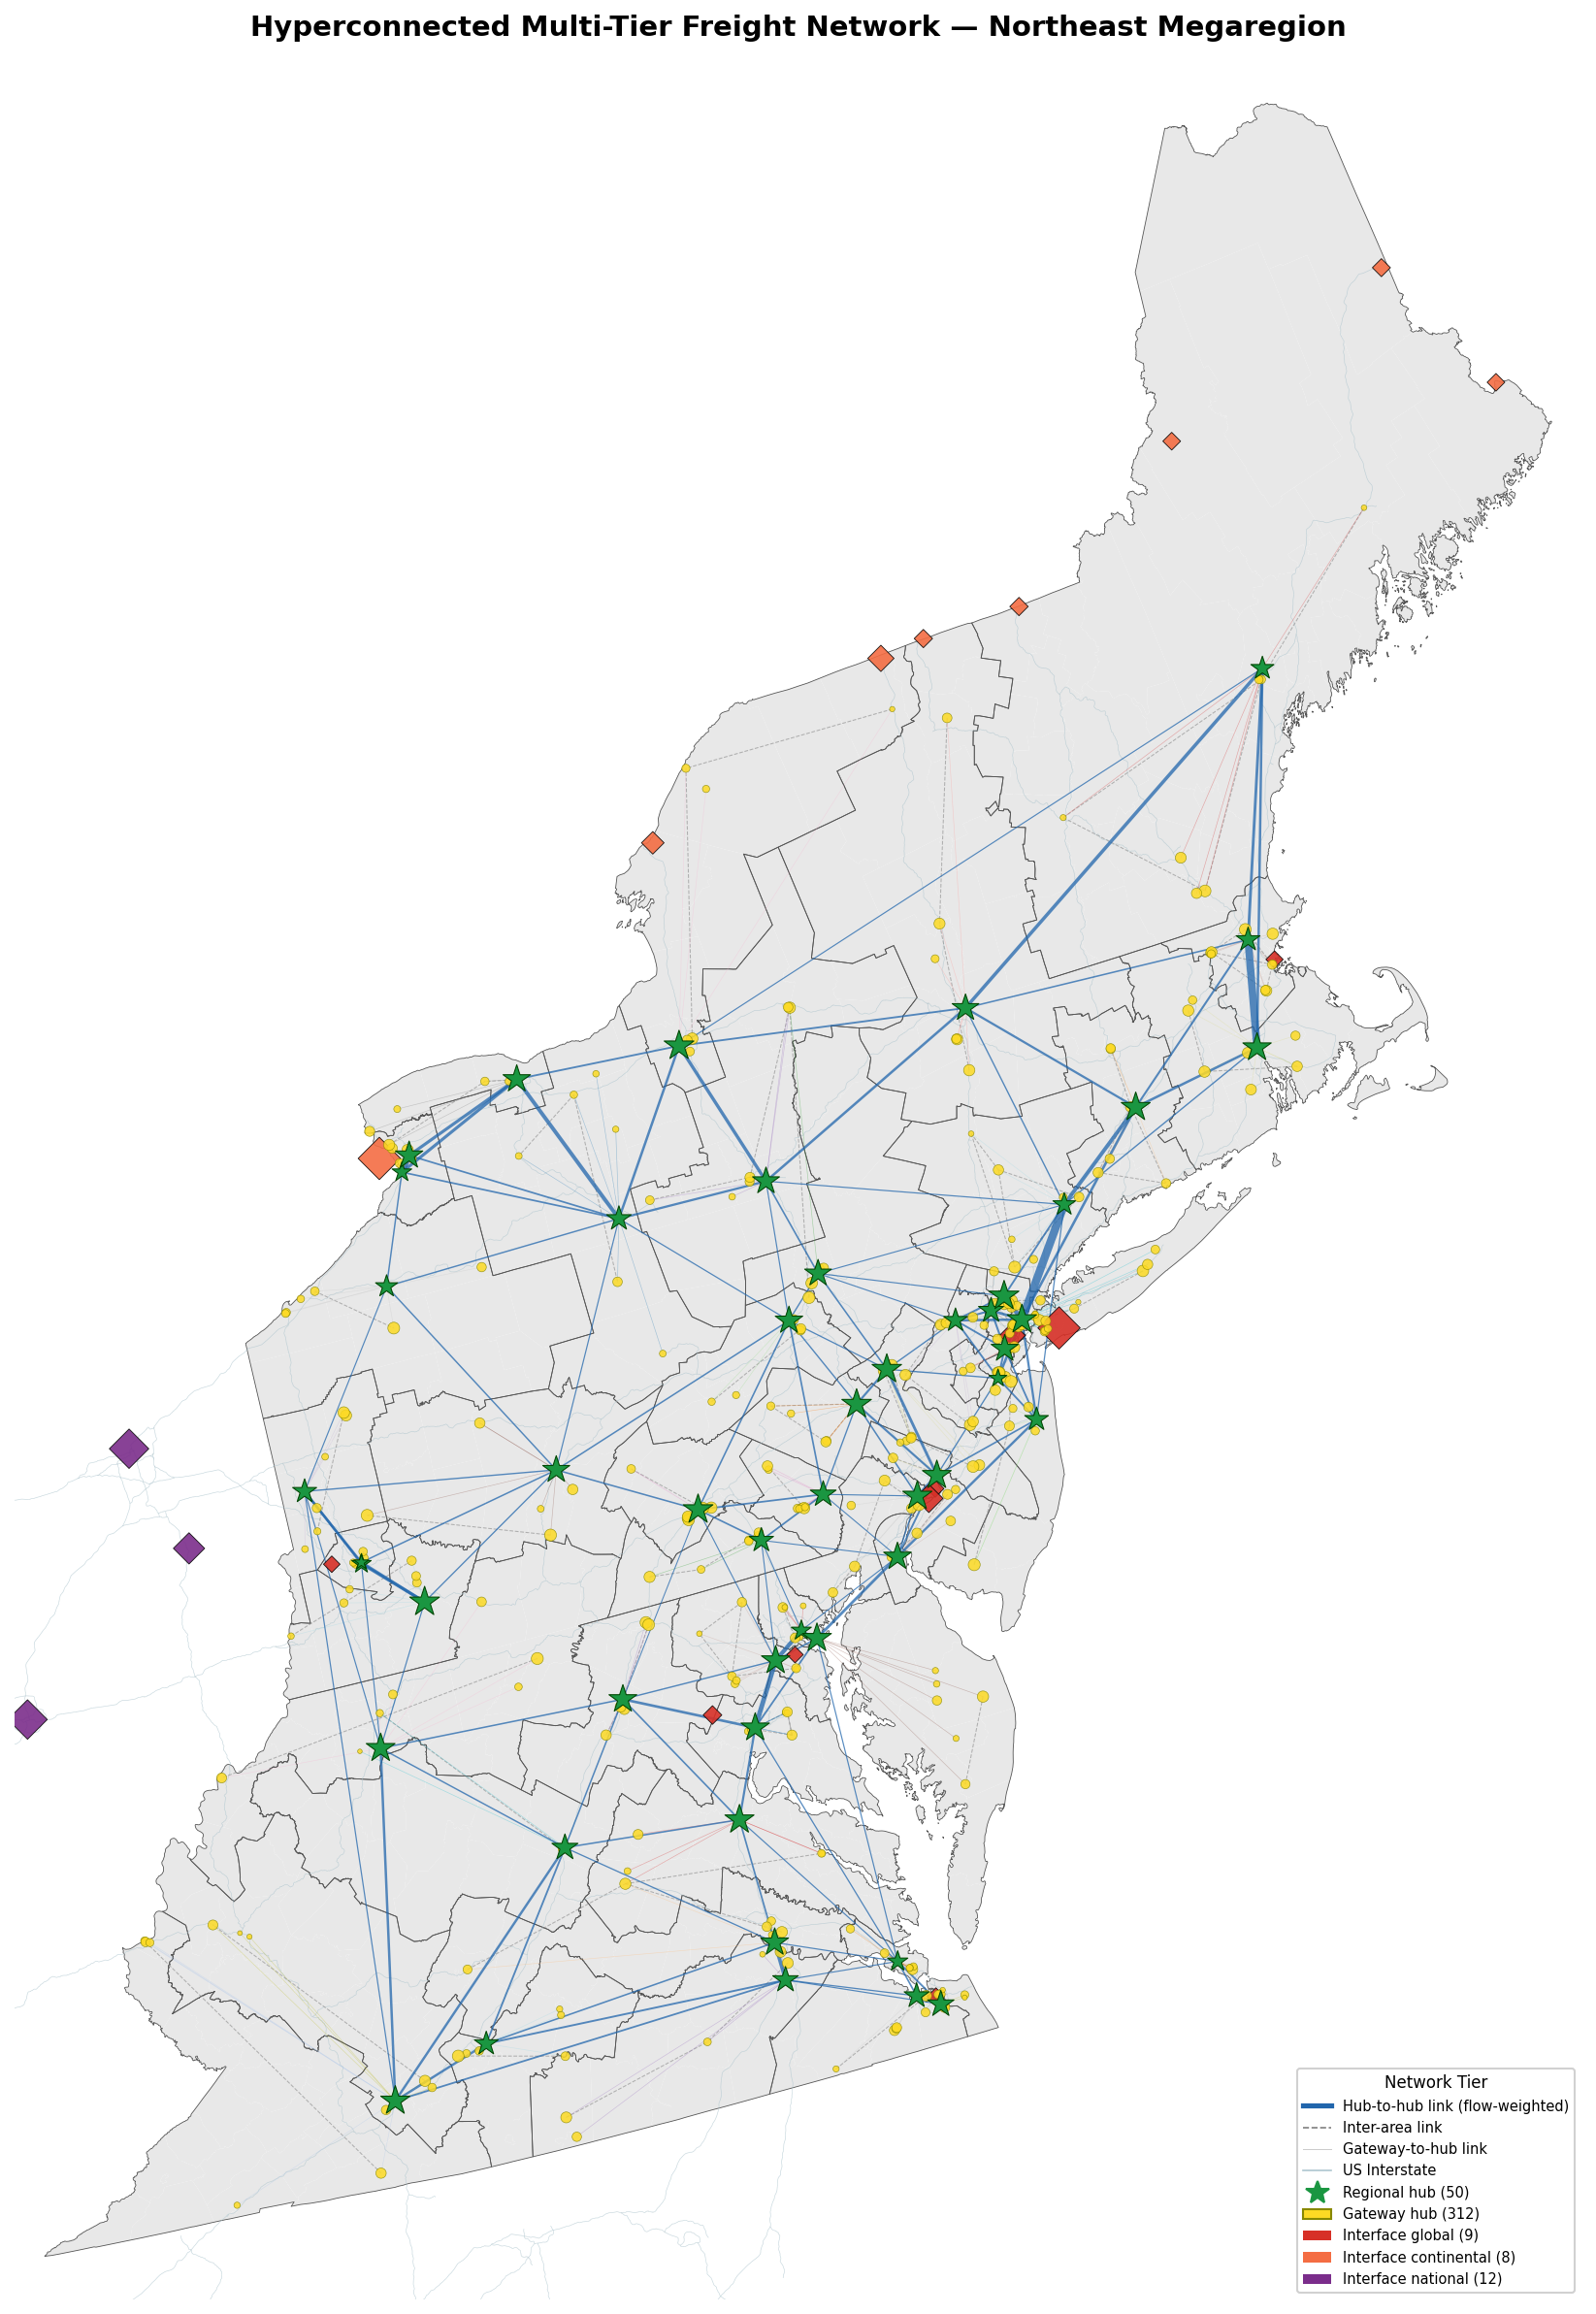


Saved: /Users/tianyihu/Documents/Dev/Python/Projects/ISYE6339_Case2/Data/Task7/figures/fig_multitier_map.png


In [13]:
# ── 7.3 — Multi-Tier Map ──────────────────────────────────────────────────────
ROAD_CACHE = D / 'Task3/cache/ne_interstates_9311.parquet'

print('Loading county GeoPackage...')
counties_gdf = gpd.read_file(D / 'Task3/derived/ne_counties_prepared.gpkg')
if counties_gdf.crs.to_epsg() != 9311:
    counties_gdf = counties_gdf.to_crs('EPSG:9311')

# Join region_id from region_assignment.csv (GeoPackage has no region_id column)
region_asgn = pd.read_csv(D / 'Task3/outputs/region_assignment.csv',
                           usecols=['fips', 'region_id'],
                           dtype={'fips': str})
region_asgn['fips'] = region_asgn['fips'].str.zfill(5)
counties_gdf['fips'] = counties_gdf['fips'].astype(str).str.zfill(5)
counties_gdf = counties_gdf.merge(region_asgn, on='fips', how='left')

# Region boundaries (dissolved)
regions_gdf = counties_gdf.dissolve(by='region_id').reset_index()

# Interstate roads
if ROAD_CACHE.exists():
    roads_gdf = gpd.read_parquet(ROAD_CACHE)
    print('Interstates loaded from cache.')
else:
    print('Loading roads shapefile (first run — may take ~30 s)...')
    roads_raw = gpd.read_file(D / 'Task3/raw/roads/North_American_Roads.shp')
    roads_gdf = roads_raw[(roads_raw['COUNTRY'] == 2) & (roads_raw['CLASS'] == 1)].to_crs('EPSG:9311')
    roads_gdf.to_parquet(ROAD_CACHE)
    print(f'Cached interstates: {len(roads_gdf)} segments.')

# NE extent in EPSG:9311
minx, miny, maxx, maxy = counties_gdf.total_bounds
pad_x = (maxx - minx) * 0.02
pad_y = (maxy - miny) * 0.02

# ── Project all nodes to EPSG:9311 for plotting ────────────────────────────
nodes_valid = nodes.dropna(subset=['latitude', 'longitude']).copy()
nx_arr, ny_arr = to_9311(nodes_valid['longitude'].to_numpy(),
                          nodes_valid['latitude'].to_numpy())
nodes_valid = nodes_valid.copy()
nodes_valid['x9311'] = nx_arr
nodes_valid['y9311'] = ny_arr
node_xy = nodes_valid.set_index('node_id')[['x9311', 'y9311']]

# Color map for region_id (0-49)
cmap_region = plt.cm.get_cmap('tab20', 50)

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 16))
ax.set_facecolor('#f0f4f8')

# Layer 1: County polygons
counties_gdf.plot(ax=ax, color='#e8e8e8', linewidth=0, zorder=1)

# Layer 2: Region boundaries
regions_gdf.boundary.plot(ax=ax, edgecolor='#555555', linewidth=0.4, zorder=2)

# Layer 3: Interstates
roads_gdf.plot(ax=ax, color='#aec6cf', linewidth=0.3, zorder=3, alpha=0.7)

# Layer 4: inter_area links
ia_edges = edges[edges['edge_type'] == 'inter_area']
ia_segs = []
for _, e in ia_edges.iterrows():
    if e['from_node_id'] in node_xy.index and e['to_node_id'] in node_xy.index:
        ax_pt = node_xy.loc[e['from_node_id']]
        bx_pt = node_xy.loc[e['to_node_id']]
        ia_segs.append([(ax_pt['x9311'], ax_pt['y9311']),
                        (bx_pt['x9311'], bx_pt['y9311'])])
if ia_segs:
    lc_ia = LineCollection(ia_segs, colors='#888888', linewidths=0.5,
                           linestyles='dashed', zorder=4, alpha=0.6)
    ax.add_collection(lc_ia)

# Layer 5: gateway_to_hub links (colored by region_id)
g2h_edges = edges[edges['edge_type'] == 'gateway_to_hub']
for _, e in g2h_edges.iterrows():
    fn, tn = e['from_node_id'], e['to_node_id']
    if fn in node_xy.index and tn in node_xy.index:
        rid = int(e['region_id']) if not pd.isna(e['region_id']) else 0
        col = cmap_region(rid % 50)
        xa, ya = node_xy.loc[fn]
        xb, yb = node_xy.loc[tn]
        ax.plot([xa, xb], [ya, yb], color=col, linewidth=0.3,
                alpha=0.35, zorder=5)

# Layer 6: hub_to_hub links (linewidth ∝ flow_intensity)
h2h_edges = edges[edges['edge_type'] == 'hub_to_hub'].copy()
fi = h2h_edges['flow_intensity_ktons'].to_numpy()
fi_norm = (fi - fi.min()) / (fi.max() - fi.min() + 1e-9)  # 0–1
lw_range = (0.5, 4.0)
lw_arr = lw_range[0] + fi_norm * (lw_range[1] - lw_range[0])
h2h_edges = h2h_edges.assign(_lw=lw_arr)

for _, e in h2h_edges.iterrows():
    fn, tn = e['from_node_id'], e['to_node_id']
    if fn in node_xy.index and tn in node_xy.index:
        xa, ya = node_xy.loc[fn]
        xb, yb = node_xy.loc[tn]
        ax.plot([xa, xb], [ya, yb], color='#2166ac', linewidth=e['_lw'],
                alpha=0.75, zorder=6)

# Layer 7: Interface nodes (diamonds, colored by interface_class)
if_class_colors = {'global': '#d73027', 'continental': '#f46d43', 'national': '#7b2d8b'}
if_nodes = nodes_valid[nodes_valid['tier'] == 3]
for iclass, color in if_class_colors.items():
    subset = if_nodes[if_nodes['interface_class'] == iclass]
    tons_vals = subset['tons_2025_ktons'].fillna(subset['tons_2025_ktons'].max())
    sizes = 20 + 200 * (tons_vals / tons_vals.max()).clip(0, 1)
    ax.scatter(subset['x9311'], subset['y9311'],
               s=sizes, c=color, marker='D', zorder=7,
               edgecolors='black', linewidths=0.4, alpha=0.9, label=f'Interface {iclass}')

# Layer 8: Gateway hubs (small yellow circles)
gw_nodes = nodes_valid[nodes_valid['tier'] == 2]
gw_sqft  = gw_nodes['usable_available_space_sf'].fillna(gw_nodes['usable_available_space_sf'].median())
gw_sizes = 5 + 30 * ((gw_sqft - gw_sqft.min()) / (gw_sqft.max() - gw_sqft.min() + 1))
ax.scatter(gw_nodes['x9311'], gw_nodes['y9311'],
           s=gw_sizes, c='#fdda24', marker='o', zorder=8,
           edgecolors='#888800', linewidths=0.3, alpha=0.85, label='Gateway hub')

# Layer 9: Regional hubs (green stars)
rh_nodes = nodes_valid[nodes_valid['tier'] == 1]
rh_sqft  = rh_nodes['usable_available_space_sf'].fillna(rh_nodes['usable_available_space_sf'].median())
rh_sizes = 60 + 180 * ((rh_sqft - rh_sqft.min()) / (rh_sqft.max() - rh_sqft.min() + 1))
ax.scatter(rh_nodes['x9311'], rh_nodes['y9311'],
           s=rh_sizes, c='#1a9641', marker='*', zorder=9,
           edgecolors='#004400', linewidths=0.5, alpha=1.0, label='Regional hub')

# Axis limits to NE extent
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_aspect('equal')
ax.axis('off')

# Legend
legend_handles = [
    mlines.Line2D([], [], color='#2166ac', linewidth=2.5, label='Hub-to-hub link (flow-weighted)'),
    mlines.Line2D([], [], color='gray', linewidth=0.8, linestyle='--', label='Inter-area link'),
    mlines.Line2D([], [], color='gray', linewidth=0.5, alpha=0.4, label='Gateway-to-hub link'),
    mlines.Line2D([], [], color='#aec6cf', linewidth=0.8, label='US Interstate'),
    mlines.Line2D([], [], color='#1a9641', marker='*', markersize=12, linestyle='None', label='Regional hub (50)'),
    mpatches.Patch(facecolor='#fdda24', edgecolor='#888800', label='Gateway hub (312)'),
    mpatches.Patch(facecolor='#d73027', label='Interface global (9)'),
    mpatches.Patch(facecolor='#f46d43', label='Interface continental (8)'),
    mpatches.Patch(facecolor='#7b2d8b', label='Interface national (12)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=7,
          framealpha=0.9, title='Network Tier', title_fontsize=8)

ax.set_title('Hyperconnected Multi-Tier Freight Network — Northeast Megaregion',
             fontsize=14, fontweight='bold', pad=12)

fig.tight_layout()
out_map = FIG / 'fig_multitier_map.png'
fig.savefig(out_map, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'\nSaved: {out_map}')

## Task 7.4 — Hierarchy Schematic

Non-geographic schematic showing the three-tier network structure and freight flow logic.

**Layout:**
- Three horizontal bands: Interface (top), Regional Hub (middle), Gateway (bottom)
- 5–8 representative nodes sampled per tier
- Directed arrows between tiers with annotation labels
- Aggregate statistics annotated on the figure

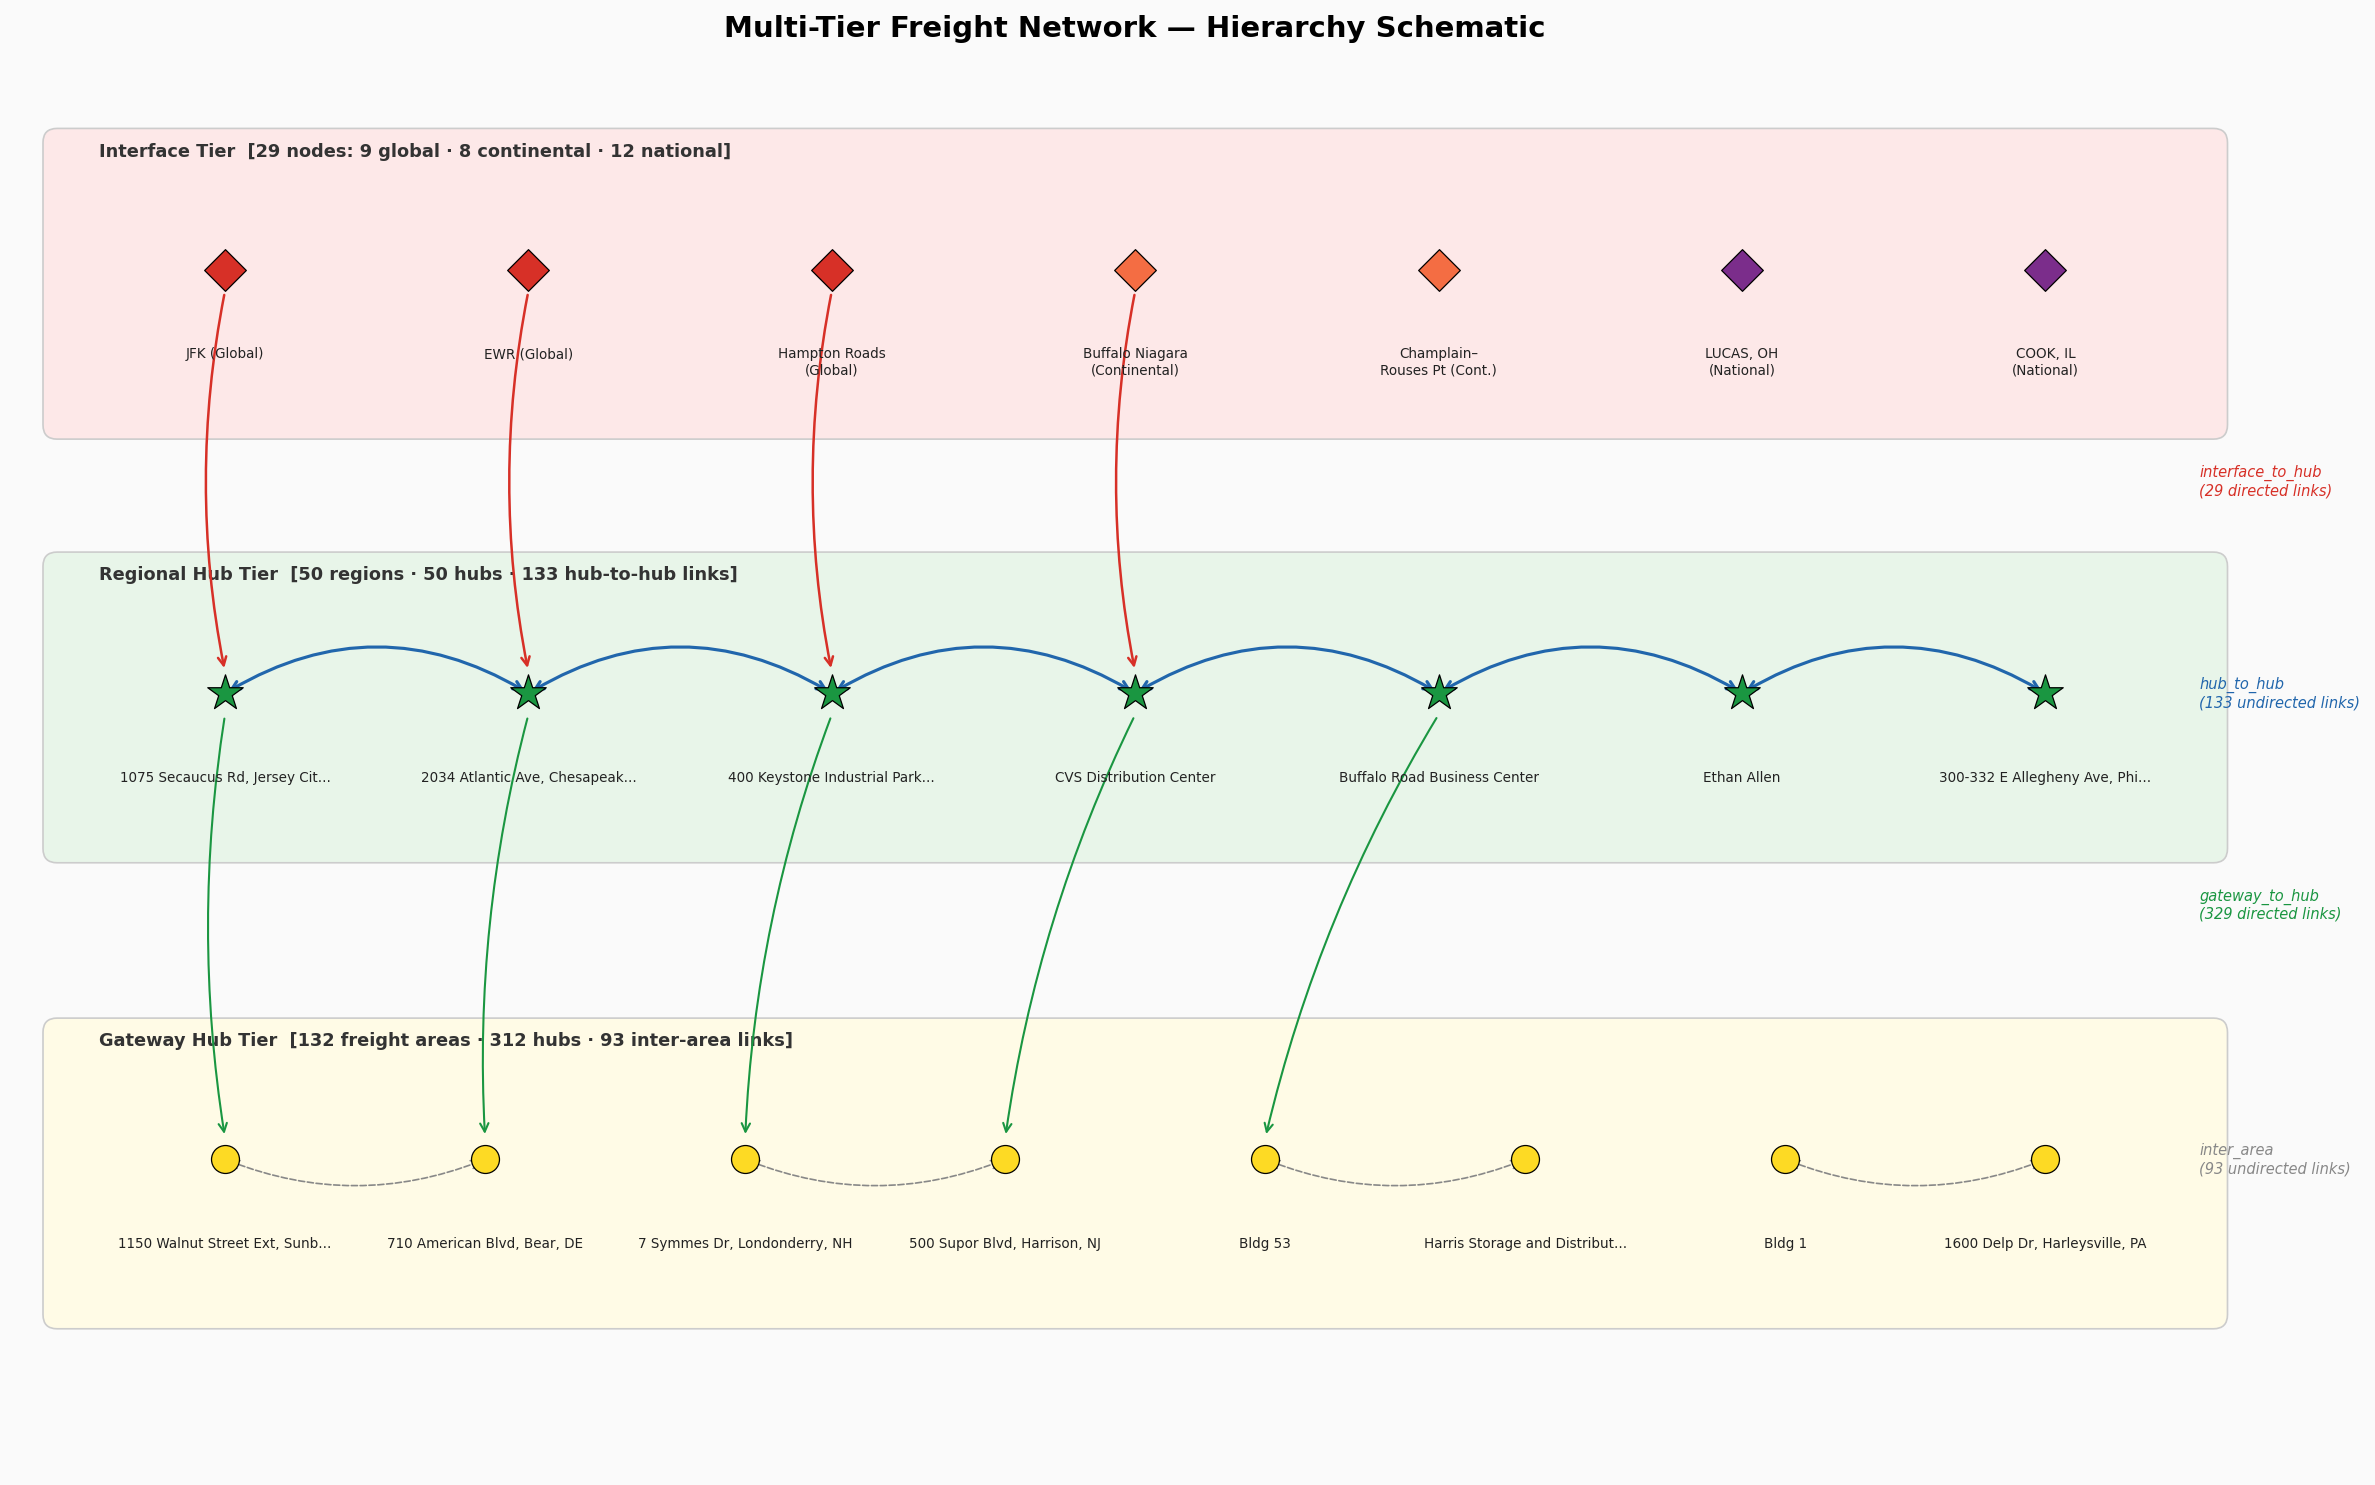

Saved: /Users/tianyihu/Documents/Dev/Python/Projects/ISYE6339_Case2/Data/Task7/figures/fig_hierarchy_schematic.png


In [14]:
# ── 7.4 — Hierarchy Schematic ─────────────────────────────────────────────────
import matplotlib.patches as FancyArrow

np.random.seed(42)

fig2, ax2 = plt.subplots(figsize=(16, 10))
ax2.set_xlim(0, 16)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_facecolor('#fafafa')
fig2.patch.set_facecolor('#fafafa')

# ── Band definitions ────────────────────────────────────────────────────────
BAND_Y = {'gateway': 2.2, 'regional': 5.5, 'interface': 8.5}
BAND_COLORS = {'gateway': '#fffbe6', 'regional': '#e8f5e9', 'interface': '#fde8e8'}

for band, y_center in BAND_Y.items():
    rect = mpatches.FancyBboxPatch((0.3, y_center - 1.1), 15.4, 2.0,
                                    boxstyle='round,pad=0.1',
                                    facecolor=BAND_COLORS[band],
                                    edgecolor='#cccccc', linewidth=0.8, zorder=0)
    ax2.add_patch(rect)

# Band labels
band_labels = {
    'gateway':   'Gateway Hub Tier  [132 freight areas · 312 hubs · 93 inter-area links]',
    'regional':  'Regional Hub Tier  [50 regions · 50 hubs · 133 hub-to-hub links]',
    'interface': 'Interface Tier  [29 nodes: 9 global · 8 continental · 12 national]',
}
for band, y_center in BAND_Y.items():
    ax2.text(0.6, y_center + 0.9, band_labels[band],
             fontsize=8.5, fontweight='bold', color='#333333', va='top', zorder=5)

# ── Sample nodes per tier (representative selection) ───────────────────────
# Interface (7): mix of global, continental, national
if_samples = [
    ('JFK (Global)', '#d73027'),
    ('EWR (Global)', '#d73027'),
    ('Hampton Roads\n(Global)', '#d73027'),
    ('Buffalo Niagara\n(Continental)', '#f46d43'),
    ('Champlain–\nRouses Pt (Cont.)', '#f46d43'),
    ('LUCAS, OH\n(National)', '#7b2d8b'),
    ('COOK, IL\n(National)', '#7b2d8b'),
]

# Regional hubs (7)
rh_samples = rh.sample(7, random_state=42)['facility_name'].tolist()

# Gateway hubs (8)
gw_samples = gw.sample(8, random_state=42)['facility_name'].tolist()

def place_nodes(ax, items, y_center, color, marker, size, label_fontsize=6.5):
    """Place evenly-spaced node circles with labels."""
    n = len(items)
    xs = np.linspace(1.5, 14.5, n)
    coords = []
    for i, (x, item) in enumerate(zip(xs, items)):
        label = item[0] if isinstance(item, tuple) else item
        node_color = item[1] if isinstance(item, tuple) else color
        ax.scatter(x, y_center, s=size, c=node_color, marker=marker,
                   edgecolors='black', linewidths=0.6, zorder=10)
        # Truncate long labels
        short = label if len(label) <= 30 else label[:28] + '...'
        ax.text(x, y_center - 0.55, short, ha='center', va='top',
                fontsize=label_fontsize, wrap=True, zorder=11, color='#222222')
        coords.append((x, y_center))
    return coords

if_coords  = place_nodes(ax2, if_samples,  BAND_Y['interface'], None,     'D', 200)
rh_coords  = place_nodes(ax2, rh_samples,  BAND_Y['regional'],  '#1a9641','*', 320)
gw_coords_ = place_nodes(ax2, gw_samples,  BAND_Y['gateway'],   '#fdda24','o', 180)

# ── Arrows: interface → regional ──────────────────────────────────────────
arrowprops_if = dict(arrowstyle='->', color='#d73027', lw=1.2,
                     connectionstyle='arc3,rad=0.1')
arrowprops_rh = dict(arrowstyle='->', color='#1a9641', lw=1.0,
                     connectionstyle='arc3,rad=0.08')

# Connect a few representative pairs
for i, (fx, fy) in enumerate(if_coords[:4]):
    tx, ty = rh_coords[i % len(rh_coords)]
    ax2.annotate('', xy=(tx, ty + 0.15), xytext=(fx, fy - 0.15),
                arrowprops=arrowprops_if, zorder=8)

# Connect a few representative pairs: regional → gateway
for j, (fx, fy) in enumerate(rh_coords[:5]):
    tx, ty = gw_coords_[j % len(gw_coords_)]
    ax2.annotate('', xy=(tx, ty + 0.15), xytext=(fx, fy - 0.15),
                arrowprops=arrowprops_rh, zorder=8)

# ── Hub-to-hub links (horizontal arcs in regional band) ───────────────────
for k in range(len(rh_coords) - 1):
    ax2.annotate('', xy=rh_coords[k + 1], xytext=rh_coords[k],
                arrowprops=dict(arrowstyle='<->', color='#2166ac', lw=1.5,
                                connectionstyle='arc3,rad=-0.3'), zorder=7)

# ── Gateway inter-area links (arcs in gateway band) ───────────────────────
for k in range(0, len(gw_coords_) - 1, 2):
    ax2.annotate('', xy=gw_coords_[k + 1], xytext=gw_coords_[k],
                arrowprops=dict(arrowstyle='<->', color='#888888', lw=0.8,
                                linestyle='dashed',
                                connectionstyle='arc3,rad=0.2'), zorder=7)

# ── Link type annotations in margins ──────────────────────────────────────
annots = [
    (15.6, 7.0,  'interface_to_hub\n(29 directed links)', '#d73027'),
    (15.6, 4.0,  'gateway_to_hub\n(329 directed links)', '#1a9641'),
    (15.6, 5.5,  'hub_to_hub\n(133 undirected links)', '#2166ac'),
    (15.6, 2.2,  'inter_area\n(93 undirected links)', '#888888'),
]
for tx, ty, label, col in annots:
    ax2.text(tx, ty, label, fontsize=7, color=col, va='center', ha='left',
             style='italic', zorder=12)

ax2.set_title('Multi-Tier Freight Network — Hierarchy Schematic',
              fontsize=14, fontweight='bold', pad=10)

fig2.tight_layout()
out_schematic = FIG / 'fig_hierarchy_schematic.png'
fig2.savefig(out_schematic, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out_schematic}')

## Task 7.5 — Exports & Validation

Final completeness checks per Task.md spec:
- Every gateway/hub `node_id` in `edges.csv` appears in `nodes.csv` (no orphan edges)
- Every regional hub in ≥ 1 hub_to_hub edge AND ≥ 1 gateway_to_hub edge
- Every interface node in exactly 1 interface_to_hub edge
- Total edge count = 133 + 329 + 93 + 29 = 584

In [15]:
# ── 7.5 — Full Validation ─────────────────────────────────────────────────────
nodes_reloaded = pd.read_csv(OUT / 'nodes.csv')
edges_reloaded = pd.read_csv(OUT / 'edges.csv')

all_nids = set(nodes_reloaded['node_id'])
edge_from = set(edges_reloaded['from_node_id'].dropna())
edge_to   = set(edges_reloaded['to_node_id'].dropna())

# 1. No orphan edge endpoints
orphans = (edge_from | edge_to) - all_nids
assert len(orphans) == 0, f'Orphan edge nodes: {orphans}'

# 2. Every regional hub in ≥1 hub_to_hub edge
h2h_e   = edges_reloaded[edges_reloaded['edge_type'] == 'hub_to_hub']
h2h_nids = set(h2h_e['from_node_id']) | set(h2h_e['to_node_id'])
rh_nids  = set(nodes_reloaded[nodes_reloaded['tier'] == 1]['node_id'])
rh_no_h2h = rh_nids - h2h_nids
if rh_no_h2h:
    print(f'WARNING — regional hubs with no hub_to_hub edge: {rh_no_h2h}')
else:
    print('✓ All regional hubs appear in ≥ 1 hub_to_hub edge')

# 3. Every regional hub in ≥1 gateway_to_hub edge
g2h_e   = edges_reloaded[edges_reloaded['edge_type'] == 'gateway_to_hub']
g2h_rh  = set(g2h_e['to_node_id'])
rh_no_gw = rh_nids - g2h_rh
if rh_no_gw:
    print(f'WARNING — regional hubs with no gateway_to_hub edge: {rh_no_gw}')
else:
    print('✓ All regional hubs appear in ≥ 1 gateway_to_hub edge')

# 4. Every interface node in exactly 1 interface_to_hub edge
if2h_e  = edges_reloaded[edges_reloaded['edge_type'] == 'interface_to_hub']
if_nids = set(nodes_reloaded[nodes_reloaded['tier'] == 3]['node_id'])
if2h_from = if2h_e['from_node_id'].value_counts()
multi_if  = if2h_from[if2h_from > 1]
missing_if = if_nids - set(if2h_e['from_node_id'])
if len(multi_if) > 0:
    print(f'WARNING — interface nodes with >1 if2h edge: {multi_if.index.tolist()}')
elif len(missing_if) > 0:
    print(f'WARNING — interface nodes with 0 if2h edges: {missing_if}')
else:
    print('✓ Every interface node has exactly 1 interface_to_hub edge')

# 5. Total edge count
total_edges = len(edges_reloaded)
assert total_edges == 584, f'Expected 584 edges, got {total_edges}'
print(f'✓ Total edge count: {total_edges} = 133+329+93+29')

# ── Summary ───────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('TASK 7 — FINAL SUMMARY')
print('='*55)
print(f'  nodes.csv : {len(nodes_reloaded)} rows (50 RH + 312 GW + 29 IF)')
print(f'  edges.csv : {len(edges_reloaded)} rows')
print(f'  Edge breakdown:')
for etype, cnt in edges_reloaded['edge_type'].value_counts().items():
    print(f'    {etype:<22} : {cnt}')
print(f'  fig_multitier_map.png      : {(FIG/"fig_multitier_map.png").exists()}')
print(f'  fig_hierarchy_schematic.png: {(FIG/"fig_hierarchy_schematic.png").exists()}')
print('='*55)
print('All validation checks passed. Task 7 complete.')

✓ All regional hubs appear in ≥ 1 hub_to_hub edge
✓ All regional hubs appear in ≥ 1 gateway_to_hub edge
✓ Every interface node has exactly 1 interface_to_hub edge
✓ Total edge count: 584 = 133+329+93+29

TASK 7 — FINAL SUMMARY
  nodes.csv : 391 rows (50 RH + 312 GW + 29 IF)
  edges.csv : 584 rows
  Edge breakdown:
    gateway_to_hub         : 329
    hub_to_hub             : 133
    inter_area             : 93
    interface_to_hub       : 29
  fig_multitier_map.png      : True
  fig_hierarchy_schematic.png: True
All validation checks passed. Task 7 complete.
